## DAY 4

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(42)

data = np.random.normal(size=100,loc=50.0,scale=10.0) # loc is teh mean , scale is the standard deviation size is teh number of samples
data_woth_dirt = data.copy()
data_woth_dirt[0] = 100000 # introduce an outliar
print("mean for prestine data:",np.mean(data))
print("mean for data with outliar:" ,np.mean(data_woth_dirt))
print(" median for prestine data:",np.median(data))
print("median for data with outliar:",np.median(data_woth_dirt))
print("HEllo")

mean for prestine data: 48.96153482605907
mean for data with outliar: 1048.411863410758
 median for prestine data: 48.73043708220287
median for data with outliar: 48.73043708220287
HEllo


In [5]:
import numpy as np

chips = np.random.normal(size=100000, loc=100.0, scale=15.0)

print("chips created")

sample = np.random.choice(chips, size=10, replace=False)

print("sample created")
print(sample)

chips created
sample created
[ 77.44802347 102.64336281  98.64712781 108.9032397  116.0597662
 135.98333961  87.09223924 122.82605548 108.14055265 113.78897395]


In [6]:
for i in range(10):
    sample = np.random.choice(chips, size=10, replace=False)
    print(i)

0
1
2
3
4
5
6
7
8
9


## WELFORD's ALGORITHM

In [4]:
chips = np.random.normal(size=100000,loc=100.0,scale=15.0)
true_variance = np.var(chips)
sample_variance = np.var(chips,ddof=1) #degree of freedom
print("true variance:", true_variance)
print("sample variance:" , sample_variance)


## empirical verification

sample_size = 10
num_trials = 1000
biased_variance = []
unbiased_variance = []

for _ in range(num_trials):
    sample = np.random.choice(chips,size=sample_size,replace=False)
    biased_variance.append(np.var(sample,ddof=0)) #ddof for true variance is 0 and for unbiased is 1
    unbiased_variance.append(np.var(sample,ddof=1)) 
print("True variance:", true_variance)
print(f"Biased Estimation (N) {np.mean(biased_variance):.4f}")
print(f"UnBiased Estimation (N-1) : {np.mean(unbiased_variance):.4f}")

print("_"*60)

true variance: 225.55390493500894
sample variance: 225.55616049661393


KeyboardInterrupt: 

In [7]:

import numpy as np

# ---------------------------------------------------------
# 1. Generate population data
# ---------------------------------------------------------

population_size = 100_000
population_mean = 100.0
population_std = 15.0

chips = np.random.normal(
    loc=population_mean,
    scale=population_std,
    size=population_size
)

# True population variance
true_variance = np.var(chips, ddof=0)

print(f"True Population Variance : {true_variance:.4f}")
print(f"Theoretical Variance      : {population_std ** 2:.4f}")


# ---------------------------------------------------------
# 2. Empirical verification
# ---------------------------------------------------------

sample_size = 10
num_trials = 1_000

biased_variances = []
unbiased_variances = []

for _ in range(num_trials):

    # Random sample of 10 observations
    sample = np.random.choice(
        chips,
        size=sample_size,
        replace=False
    )

    # Variance using N
    biased_variance = np.var(sample, ddof=0)

    # Variance using N - 1
    unbiased_variance = np.var(sample, ddof=1)

    biased_variances.append(biased_variance)
    unbiased_variances.append(unbiased_variance)


# ---------------------------------------------------------
# 3. Compare the estimators
# ---------------------------------------------------------

average_biased_variance = np.mean(biased_variances)
average_unbiased_variance = np.mean(unbiased_variances)

print("\n" + "-" * 60)
print("EMPIRICAL VERIFICATION")
print("-" * 60)

print(f"True Population Variance       : {true_variance:.4f}")
print(f"Average Biased Variance (N)    : {average_biased_variance:.4f}")
print(f"Average Unbiased Variance (N-1): {average_unbiased_variance:.4f}")

print("-" * 60)


True Population Variance : 226.0760
Theoretical Variance      : 225.0000

------------------------------------------------------------
EMPIRICAL VERIFICATION
------------------------------------------------------------
True Population Variance       : 226.0760
Average Biased Variance (N)    : 203.0012
Average Unbiased Variance (N-1): 225.5569
------------------------------------------------------------


## Percentile

A percentile is a measure used in statistics indicating the value below which a given percentage of observations in a group of observations fall. For example, the 20th percentile is the value

Extemal Libran

Scratches and

main.py

01.ipynb

50th percentile is the value below which 50 percent of the observations may be found.

90th percentile is the value below which 90 percent of the observations may be found.

99th percentile is the value below which 99 percent of the observations may be found

In [9]:
def percentile(scores, target_score):
    less_count = sum(1 for s in scores if s < target_score)
    percentile = (less_count / len(scores)) * 100
    return percentile

test_scores = [min (84 ,50 +i) for i in range(90)] + [85] + [min(99,86 + i) for i in range(9)]
print("Test scores :", test_scores)


Test scores : [50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]


In [12]:
score = [50,60,70,75,75,75,75,85,90,95]
target = 75
# strict percentile considers only the scores strictly less than the target 

percentile_of_target_strict = stats.percentileofscore(score,target,kind='strict')
percentile_of_target_rank = stats.percentileofscore(score,target,kind='rank')
print(f"percentile of {target} (strict): {percentile_of_target_strict:.1f}th percentile")
print(f"percentile of {target} (rank): {percentile_of_target_rank:.1f}th percentile")

percentile of 75 (strict): 30.0th percentile
percentile of 75 (rank): 55.0th percentile


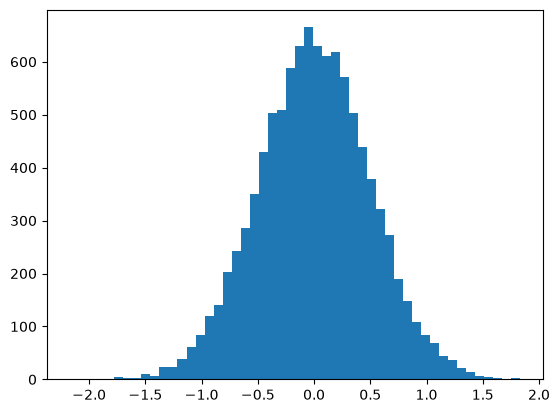

In [14]:
vals = np.random.normal(0,0.5,10000)
plt.hist(vals,bins=50)
plt.show()

In [15]:
percentiles = [50,90,20]
percentile_values = np.percentile(vals,percentiles)
for p ,v in zip(percentiles , percentile_values):
    print(f"{p}th percentile: {v}")



50th percentile: -0.0014504960335722074
90th percentile: 0.6311427450243683
20th percentile: -0.41517972128183117
